# CarbonLens
# UIC CS 418, Fall 2025 Final Project
**Authors: Karthik Kesavarapu, Shri Chatrati, Shounak Sawant, Rahee Chauhan**

## Project Introduction:

As there is an increasing concern about the prevalent issues that are starting to arise with global warming, consumers are starting to become more aware of the products that release more carbon emmissions. However, some applications may not include specific carbon data, and if they do consumers are not sure if it is the appropriate and eco-friendly which ultimately leaves buyers unaware of the true environmental cost of their choices. CarbonLens aims to solve this problem by predicting the CO2 emissions of appliances using machine learning, based on publicly available features such as energy usage, materials, and origin. 

The purpose of this application is to hypothesize whether or not a product's CO2 emissions can be accurately estimated with quantitative and qualitative being predicted. In other words, we propose that machine learnning can estimate the carbon footprint of appliances based on standard specification data, which will increase customer awareness of environmental impact. 

## Project Changes Since Proposal:
One of the major changes since the project proposal was the scope of the data. Our plan originally had a CO2 emmissions dataset and a database. We are choosing as a group to get rid of these two datasets as it confuses of what the scope of the project actually is. The very first dataset that we have just talks about the carbon emmissions over time which alraedy has a data visualization in the website. Furthermore, it is common knowledge, we also assume that our audience knows this, that the industrial revolution in 1960 caused a rise of CO2 emmissions. Instead of these two datasets, we are opting to choose a dataset from energystar.gov which is a US private company that keeps track of emmissions of different appliances. This also solidifies the scope of the project as now our project will examine the CO2 Emissions in the United Staes of America. 

## Energy Star Certified Product Data Sets
Within this dataset, there are so many different appliances that are grouped by different categories. We have decided to pick categories that people are expected to use almost daily which includes appliances, heating and cooling, electronics and home office, lighting and fans, and vehicle charging. Althoguh this may seem like a bias for appliances that will emmit a lot more carbon dioxide because it is used more, it falls under the scope of the project because we are trying to find out the patterns of CO2 emmissions from daily used products. From these different appliances, we used a simple random sample (SRS) so that all of the appliances have an equal opportunity of being picked. 

The appliances that we are going to use are:
1. Refrigerators
2. Room Air Conditioners
3. Televisions
4. Ceiling Fans
5. Ovens

This is a good stratification of 5 different types of appliances that will show the overall trends of CO2 usage in daily appliances

## Imports for this project:

In [482]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import date, datetime
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from collections import Counter
import seaborn as sns

## Part I: Data Preparation
In this section, we are going to prepare the data from the source.

### Obtaining and Cleaning Refrigerator Data

In [483]:
dfRefrigerator = pd.read_csv('Residential Refrigerators.csv')
# Display the first few rows of the dataframe
print(dfRefrigerator.head())
print(dfRefrigerator.columns.tolist())

   ENERGY STAR Unique ID Brand Name    Model Number  \
0                4015668        ABL        AREF18**   
1                4015667        ABL         AREF18B   
2                4015665        ABL         AREF18S   
3                4015666        ABL         AREF18W   
4                2403036   Absocold  ARD1033FB21R/L   

  Additional Model Information  UPC         Type  \
0                          NaN  NaN  Top Freezer   
1                          NaN  NaN  Top Freezer   
2                          NaN  NaN  Top Freezer   
3                          NaN  NaN  Top Freezer   
4                          NaN  NaN  Top Freezer   

                                       Product Class Defrost Type Compact  \
0  3 - Refrigerator-freezers - automatic defrost ...    Automatic      No   
1  3 - Refrigerator-freezers - automatic defrost ...    Automatic      No   
2  3 - Refrigerator-freezers - automatic defrost ...    Automatic      No   
3  3 - Refrigerator-freezers - automatic defrost

This is a lot of columns with a lot of data information. Let's try cleaning it up!

In [484]:
# 1. Drop duplicates
dfRefrigerator = dfRefrigerator.drop_duplicates()

# 2. Remove completely empty columns
dfRefrigerator = dfRefrigerator.dropna(axis=1, how='all')

# 3. Remove rows missing key values
dfRefrigerator = dfRefrigerator.dropna(subset=["Brand Name", "Model Number", "Annual Energy Use (kWh/yr)", "Additional Model Information"])

# 4. Convert numeric columns to proper types
numeric_cols = [
    "Annual Energy Use (kWh/yr)",
    "US Federal Standard (kWh/yr)",
    "Percent Less Energy Use than US Federal Standard",
    "Height (in)",
    "Width (in)",
    "Capacity (Total Volume) (ft3)"
]
dfRefrigerator[numeric_cols] = dfRefrigerator[numeric_cols].apply(pd.to_numeric, errors="coerce")

# 5. Drop rows with invalid or 0 energy values
dfRefrigerator = dfRefrigerator[dfRefrigerator["Annual Energy Use (kWh/yr)"] > 0]

# 6. Standardize brand names
dfRefrigerator["Brand Name"] = dfRefrigerator["Brand Name"].str.strip().str.title()

# 7. Convert all Yes/No columns to 1/0
for col in dfRefrigerator.columns:
    if dfRefrigerator[col].isin(['Yes', 'No']).any():
        dfRefrigerator[col] = dfRefrigerator[col].replace({'Yes': 1, 'No': 0})


# 8. Reset index
dfRefrigerator = dfRefrigerator.reset_index(drop=True)

# 9. Convert date columns to proper datetime objects
date_cols = ["Date Available On Market", "Date Certified"]
for col in date_cols:
    dfRefrigerator[col] = pd.to_datetime(dfRefrigerator[col], format="%m/%d/%Y", errors="coerce")

# 10. Preview cleaned data
print(dfRefrigerator.info())
print(dfRefrigerator.head())

# 11. Save Cleaned File
dfRefrigerator.to_csv("Refrigerators_Cleaned.csv", index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 604 entries, 0 to 603
Data columns (total 32 columns):
 #   Column                                                  Non-Null Count  Dtype         
---  ------                                                  --------------  -----         
 0   ENERGY STAR Unique ID                                   604 non-null    int64         
 1   Brand Name                                              604 non-null    object        
 2   Model Number                                            604 non-null    object        
 3   Additional Model Information                            604 non-null    object        
 4   UPC                                                     375 non-null    object        
 5   Type                                                    602 non-null    object        
 6   Product Class                                           604 non-null    object        
 7   Defrost Type                                            593 no

/var/folders/10/k1hzxcd55vlfmyc_qrppm9980000gn/T/ipykernel_31404/1355213630.py:30: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dfRefrigerator[col] = dfRefrigerator[col].replace({'Yes': 1, 'No': 0})


### Obtaining and Cleaning the Air Conditioner Data

In [485]:
dfAirConditioner = pd.read_csv('Room Air Conditioners.csv')
# Display the first few rows of the dataframe
print(dfAirConditioner.head())
print(dfAirConditioner.columns.tolist())

   ENERGY STAR Unique ID    Brand Name Model Number  \
0                3387785  BLACK+DECKER     BD08NWES   
1                3387786  BLACK+DECKER     BD10NWES   
2                3387787  BLACK+DECKER     BD12NWES   
3                3629713       Century    RXTS-101A   
4                3629714       Century    RXTS-121A   

  Additional Model Information           UPC  Height (inches)  Width (inches)  \
0                          NaN  810064695360             13.5            18.6   
1                          NaN  810064695377             13.5            18.6   
2                          NaN  810064695384             14.6            19.1   
3                          NaN           NaN             13.5            19.2   
4                          NaN           NaN             13.5            19.2   

   Depth (inches)  Weight (lbs) Cooling Capacity (Btu/hr)  ...  \
0            19.6          44.1                     8,000  ...   
1            19.6          46.1                   

In [486]:
# ----------------------------------------------------
# 1. Drop duplicates
# ----------------------------------------------------
dfAC = dfAirConditioner.drop_duplicates()

# ----------------------------------------------------
# 2. Remove fully empty columns
# ----------------------------------------------------
dfAC = dfAC.dropna(axis=1, how='all')

# ----------------------------------------------------
# 3. Clean Cooling Capacity (remove commas, convert)
# ----------------------------------------------------
dfAC["Cooling Capacity (Btu/hr)"] = (
    dfAC["Cooling Capacity (Btu/hr)"]
    .astype(str)
    .str.replace(",", "", regex=True)
)

dfAC["Cooling Capacity (Btu/hr)"] = pd.to_numeric(
    dfAC["Cooling Capacity (Btu/hr)"], errors="coerce"
)

# ----------------------------------------------------
# 4. Convert other numeric columns
# ----------------------------------------------------
num_cols = [
    "Annual Energy Use (kWh/yr)",
    "Voltage (volts)",
    "Percent Less Energy Use than US Federal Standard",
    "Combined Energy Efficiency Ratio (CEER)"
]

for col in num_cols:
    dfAC[col] = pd.to_numeric(dfAC[col], errors="coerce")

# ----------------------------------------------------
# 5. Drop rows missing essential information
# ----------------------------------------------------
dfAC = dfAC.dropna(subset=[
    "Brand Name",
    "Model Number",
    "Cooling Capacity (Btu/hr)",
    "Annual Energy Use (kWh/yr)"
])

# ----------------------------------------------------
# 6. Standardize brand names
# ----------------------------------------------------
dfAC["Brand Name"] = dfAC["Brand Name"].str.strip().str.title()

# ----------------------------------------------------
# 7. Convert yes/no → 1/0
# ----------------------------------------------------
for col in dfAC.columns:
    if dfAC[col].isin(["Yes", "No"]).any():
        dfAC[col] = dfAC[col].replace({"Yes": 1, "No": 0})

# ----------------------------------------------------
# 8. Convert date columns
# ----------------------------------------------------
for col in ["Date Available On Market", "Date Certified"]:
    dfAC[col] = pd.to_datetime(dfAC[col], errors="coerce")

# ----------------------------------------------------
# 9. Reset index
# ----------------------------------------------------
dfAC = dfAC.reset_index(drop=True)

# ----------------------------------------------------
# 10. Save cleaned file
# ----------------------------------------------------
dfAC.to_csv("AirConditioners_Cleaned.csv", index=False)

print(dfAC.info())
print(dfAC.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 255 entries, 0 to 254
Data columns (total 28 columns):
 #   Column                                            Non-Null Count  Dtype         
---  ------                                            --------------  -----         
 0   ENERGY STAR Unique ID                             255 non-null    int64         
 1   Brand Name                                        255 non-null    object        
 2   Model Number                                      255 non-null    object        
 3   Additional Model Information                      14 non-null     object        
 4   UPC                                               195 non-null    object        
 5   Height (inches)                                   255 non-null    float64       
 6   Width (inches)                                    255 non-null    float64       
 7   Depth (inches)                                    255 non-null    float64       
 8   Weight (lbs)                  

/var/folders/10/k1hzxcd55vlfmyc_qrppm9980000gn/T/ipykernel_31404/3384814081.py:57: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dfAC[col] = dfAC[col].replace({"Yes": 1, "No": 0})


### Obtaining and Cleaning the Television Data

In [487]:
dfTelevisionData = pd.read_csv('Televisions.csv')
# Display the first few rows of the dataframe
print(dfTelevisionData.head())
print(dfTelevisionData.columns.tolist())

   ENERGY STAR Unique ID                                ENERGY STAR Partner  \
0                2402123                          Curtis International Ltd.   
1                2403227  ELITELUX TECHNOLOGIES,INC./GLOBAL Q. INTERNATI...   
2                3554271  ELITELUX TECHNOLOGIES,INC./GLOBAL Q. INTERNATI...   
3                2399940  ELITELUX TECHNOLOGIES,INC./GLOBAL Q. INTERNATI...   
4                3554326  ELITELUX TECHNOLOGIES,INC./GLOBAL Q. INTERNATI...   

  Brand Name Model Name Model Number  \
0        RCA       65D1         65D1   
1     Sansui    LE-24T1      LE-24T1   
2     Sansui   LE-24TA1     LE-24TA1   
3     Sansui    LE-32T1      LE-32T1   
4     Sansui    LE-32V1      LE-32V1   

                        Additional Model Information  UPC     Product Type  \
0  ,65N1,; ,RTAU6504,; ,RTAU6540.,; ,RTRU6527,; ,...  NaN  Television (TV)   
1  ,EC24T1H,; ,EC24T1HA,; ,EC24T1HN,; ,EC24T2H,; ...  NaN  Television (TV)   
2  ,****24****.,; ,C24V1HW,; ,C24VAHW,; ,LE-24T1,.

In [488]:
# 1. Drop duplicates
dfTelevisionData = dfTelevisionData.drop_duplicates()

# 2. Drop fully empty columns
dfTelevisionData = dfTelevisionData.dropna(axis=1, how='all')

# 3. Drop rows missing essential identifiers
dfTelevisionData = dfTelevisionData.dropna(subset=["Brand Name", "Model Number", "Reported Annual Energy Consumption (kWh)"])

# 4. Clean numeric columns
numeric_cols = [
    "Reported Annual Energy Consumption (kWh)",
    "Average On Mode Power Consumption for Certification (watts)",
    "Maximum Average On Mode Power for Certification (watts)",
    "Reported On Mode Power (per the Federal Test Procedure) (watts)",
    "Measured Standby Mode Power (Watts)",
    "Power Consumption in Standby Mode when Not Connected to a Network (watts)",
    "Power Consumption in Standby Mode when Connected to a Network (watts)",
    "Reported Standby-Active, Low Mode Power (watts)",
    "Diagonal Viewable Screen Size (in.)",
    "Screen Area (sq. in.)",
    "Native Horizontal Resolution (pixels)",
    "Native Vertical Resolution (pixels)"
]

for col in numeric_cols:
    if col in dfTelevisionData.columns:
        if dfTelevisionData[col].dtype == object:
            dfTelevisionData[col] = dfTelevisionData[col].str.replace(',', '', regex=True)
        dfTelevisionData[col] = pd.to_numeric(dfTelevisionData[col], errors="coerce")

# 5. Remove rows with invalid or zero energy consumption
dfTelevisionData = dfTelevisionData[dfTelevisionData["Reported Annual Energy Consumption (kWh)"] > 0]

# 6. Normalize brand names
dfTelevisionData["Brand Name"] = dfTelevisionData["Brand Name"].str.strip().str.title()

# 7. Convert Yes/No to 1/0
for col in dfTelevisionData.columns:
    if dfTelevisionData[col].isin(['Yes', 'No']).any():
        dfTelevisionData[col] = dfTelevisionData[col].replace({'Yes': 1, 'No': 0})

# 8. Convert date columns to datetime
date_cols = ["Date Available On Market", "Date Certified"]
for col in date_cols:
    dfTelevisionData[col] = pd.to_datetime(dfTelevisionData[col], format="%m/%d/%Y", errors="coerce")

# 9. Reset index
dfTelevisionData = dfTelevisionData.reset_index(drop=True)

# 10. Preview cleaned data
print(dfTelevisionData.info())
print(dfTelevisionData.head())

# 11. Save Cleaned File
dfTelevisionData.to_csv("Televisions_Cleaned.csv", index=False)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 146 entries, 0 to 145
Data columns (total 35 columns):
 #   Column                                                                                                                    Non-Null Count  Dtype         
---  ------                                                                                                                    --------------  -----         
 0   ENERGY STAR Unique ID                                                                                                     146 non-null    int64         
 1   ENERGY STAR Partner                                                                                                       146 non-null    object        
 2   Brand Name                                                                                                                146 non-null    object        
 3   Model Name                                                                                          

/var/folders/10/k1hzxcd55vlfmyc_qrppm9980000gn/T/ipykernel_31404/807767605.py:41: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dfTelevisionData[col] = dfTelevisionData[col].replace({'Yes': 1, 'No': 0})


### Obtaining and Cleaning Data the Ceiling Fans Data

In [489]:
dfCeilingFans = pd.read_csv('Ceiling Fans.csv')
# Display the first few rows of the dataframe
print(dfCeilingFans.head())
print(dfCeilingFans.columns.tolist())

   ENERGY STAR Unique ID ENERGY STAR Partner Brand Name   Model Name  \
0                2386171    Aeratron Pty Ltd   AERATRON  Ceiling Fan   
1                2385543    Aeratron Pty Ltd   AERATRON  Ceiling Fan   
2                2386170    Aeratron Pty Ltd   AERATRON  Ceiling Fan   
3                2385542    Aeratron Pty Ltd   AERATRON  Ceiling Fan   
4                2386169    Aeratron Pty Ltd   AERATRON  Ceiling Fan   

   Model Number              Additional Model Information  \
0   AE+2WI43***  ,,Each * to represent a letter or blank.   
1  AE+2WI43L***  ,,Each * to represent a letter or blank.   
2   AE+2WI50***  ,,Each * to represent a letter or blank.   
3  AE+2WI50L***  ,,Each * to represent a letter or blank.   
4   AE+2WI60***  ,,Each * to represent a letter or blank.   

                                                 UPC      Indoor/Outdoor  \
0  850021862015;850021862022;850021862039;8500218...  Indoor Ceiling Fan   
1  850021862015;850021862022;850021862039;850021

In [490]:
# 1. Clean column names (remove hidden spaces)
dfCeilingFans.columns = dfCeilingFans.columns.str.strip()

# 2. Drop duplicates
dfCeilingFans = dfCeilingFans.drop_duplicates()

# 3. Drop fully empty columns
dfCeilingFans = dfCeilingFans.dropna(axis=1, how='all')

# 4. Remove rows missing key info
dfCeilingFans = dfCeilingFans.dropna(subset=["Brand Name", "Model Number", "Ceiling Fan Efficiency (CFM/W)"])

# 5. Convert numeric columns
numeric_cols = [
    "Blade Span (Diameter) (in.)",
    "Ceiling Fan Efficiency (CFM/W)",
    "Fan Power Consumption-Low Speed (W)",
    "Fan Power Consumption-High Speed (W)",
    "Fan Power Consumption-Standby (W)",
    "Ceiling Fan Components Warranty (Years)",
    "Total Light Output (lumens)",
    "Total Lighting Input Power (Watts)",
    "Lighting Efficiency – Measured outside the Fixture (lm/W)",
    "Lighting Efficiency – Measured at the Source (lm/W)",
    "Power Factor of Light Kit",
    "Light Color Appearance (CCT)",
    "Light Color Quality (CRI)",
    "Light Source Rated Life (Hours)",
    "Light Sources Per Light Kit",
    "Ceiling Fan Light Kit Warranty (yrs)"
]

for col in numeric_cols:
    if col in dfCeilingFans.columns:
        if dfCeilingFans[col].dtype == object:
            dfCeilingFans[col] = dfCeilingFans[col].str.replace(',', '', regex=True)
        dfCeilingFans[col] = pd.to_numeric(dfCeilingFans[col], errors="coerce")

# 6. Drop rows with invalid or zero efficiency
dfCeilingFans = dfCeilingFans[dfCeilingFans["Ceiling Fan Efficiency (CFM/W)"] > 0]

# 7. Normalize brand names
dfCeilingFans["Brand Name"] = dfCeilingFans["Brand Name"].str.strip().str.title()

# 8. Convert Yes/No columns to 1/0
for col in dfCeilingFans.columns:
    if dfCeilingFans[col].isin(['Yes', 'No']).any():
        dfCeilingFans[col] = dfCeilingFans[col].replace({'Yes': 1, 'No': 0})

# 9. Convert dates to datetime
from datetime import datetime
date_cols = ["Date Available on Market", "Date Certified"]
for col in date_cols:
    if col in dfCeilingFans.columns:
        dfCeilingFans[col] = pd.to_datetime(dfCeilingFans[col], format="%m/%d/%Y", errors="coerce")

# 10. Reset index
dfCeilingFans = dfCeilingFans.reset_index(drop=True)

# 11. Preview cleaned data
print(dfCeilingFans.info())
print(dfCeilingFans.head())

# 12. Save Cleaned File
dfCeilingFans.to_csv("CeilingFans_Cleaned.csv", index=False)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1144 entries, 0 to 1143
Data columns (total 32 columns):
 #   Column                                          Non-Null Count  Dtype         
---  ------                                          --------------  -----         
 0   ENERGY STAR Unique ID                           1144 non-null   int64         
 1   ENERGY STAR Partner                             1144 non-null   object        
 2   Brand Name                                      1144 non-null   object        
 3   Model Name                                      1144 non-null   object        
 4   Model Number                                    1144 non-null   object        
 5   Additional Model Information                    542 non-null    object        
 6   UPC                                             642 non-null    object        
 7   Indoor/Outdoor                                  1144 non-null   object        
 8   Product Type                                    

/var/folders/10/k1hzxcd55vlfmyc_qrppm9980000gn/T/ipykernel_31404/3209051774.py:48: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dfCeilingFans[col] = dfCeilingFans[col].replace({'Yes': 1, 'No': 0})


### Obtaining and Cleaning Data the Ovens Data

In [491]:
dfOvens = pd.read_csv('Ovens.csv')
# Display the first few rows of the dataframe
print(dfOvens.head())
print(dfOvens.columns.tolist())

   ENERGY STAR Unique ID ENERGY STAR Partner                    Brand Name  \
0                3942789    Alto-Shaam, Inc.                    Alto-Shaam   
1                3722150    Alto-Shaam, Inc.  Alto-Shaam - Prodigi Classic   
2                3722082    Alto-Shaam, Inc.  Alto-Shaam - Prodigi Classic   
3                2407803    Alto-Shaam, Inc.  Alto-Shaam - Prodigi Classic   
4                2407802    Alto-Shaam, Inc.      Alto-Shaam - Prodigi Pro   

  Model Name Model Number Additional Model Information  UPC Product Type  \
0  CTP10-20G    CTP10-20G                          NaN  NaN  Combination   
1  CTC20-10G    CTC20-10G                          NaN  NaN  Combination   
2  CTC20-20E    CTC20-20E                          NaN  NaN  Combination   
3  CTP20-20G    CTP20-20G                          NaN  NaN  Combination   
4  CTC20-20G    CTC20-20G                          NaN  NaN  Combination   

                                 Oven Classification       Size  ...  \
0 

In [492]:
# 1) Drop dups / empty cols
dfOvens = dfOvens.drop_duplicates()
dfOvens = dfOvens.dropna(axis=1, how='all')

# 2) Drop rows missing core identifiers
core_cols = ["Brand Name", "Model Number", "Product Type"]
present_core = [c for c in core_cols if c in dfOvens.columns]
if present_core:
    dfOvens = dfOvens.dropna(subset=present_core)

# 3) Numeric conversions (only if column exists)
numeric_cols = [
    "Input Rate (kW)",
    "Input Rate (Btu/hr)",
    "Gas Oven Convection Mode Pre-Heat Energy (Btu)",
    "Electric Oven Convection Mode Pre-Heat Energy (kWh)",
    "Convection Mode Pre-Heat Time (min)",
    "Gas Oven Steam Mode Pre-Heat Energy (Btu)",
    "Electric Oven Steam Mode Pre-Heat Energy (kWh)",
    "Steam Mode Pre-Heat Time (min)",
    "Electric Oven Convection Mode Idle Energy Rate (kW)",
    "Gas Oven Convection Mode Idle Energy Rate (Btu/hr)",
    "Gas Oven Convection Mode Electric Idle Energy Rate (kW)",
    "Gas Oven Convection Mode Total Idle Energy Rate (Btu/hr)",
    "Half-Size and Full-Size Steam Pan Capacity",
    "Two-Thirds-Size Steam Pan Capacity",
    "Half-Size Sheet Pan Capacity",
    "Full-Size Sheet Pan Capacity",
    "Electric Oven Steam Mode Idle Energy Rate (kW)",
    "Gas Oven Steam Mode Idle Energy Rate (Btu/hr)",
    "Gas Oven Steam Mode Electric Idle Energy Rate (kW)",
    "Gas Oven Steam Mode Total Idle Energy Rate (Btu/hr)",
    "Convection Mode Cooking Energy Efficiency (%)",
    "Steam Mode Cooking Energy Efficiency (%)",
    "Convection Mode Production Capacity (lbs/hr)",
    "Steam Mode Production Capacity (lbs/hr)",
    "Convection Mode Cooking Period Water Consumption (gal/pan)",
    "Convection Mode Idle Period Water Consumption (gal/hr/pan)",
    "Steam Mode Cooking Period Water Consumption (gal/pan)",
    "Steam Mode Idle Period Water Consumption (gal/hr/pan)",
    "Rack Oven Baking-Energy Efficiency (%)",
    "Baking Production Capacity (lbs/hr)",
    "Steam Injection Period Water Consumption (gal/min)"
]

for col in numeric_cols:
    if col in dfOvens.columns:
        # strip and remove commas
        dfOvens[col] = (
            dfOvens[col]
            .astype(str)
            .str.strip()
            .str.replace(",", "", regex=True)
            .replace({"": None})
        )
        dfOvens[col] = pd.to_numeric(dfOvens[col], errors="coerce")

# 4) Normalize brand names
if "Brand Name" in dfOvens.columns:
    dfOvens["Brand Name"] = dfOvens["Brand Name"].astype(str).str.strip().str.title()

# 5) Yes/No -> 1/0
for col in dfOvens.columns:
    if dfOvens[col].isin(["Yes", "No"]).any():
        dfOvens[col] = dfOvens[col].replace({"Yes": 1, "No": 0})

# 6) Date parsing
for dcol in ["Date Available on Market", "Date Certified"]:
    if dcol in dfOvens.columns:
        dfOvens[dcol] = pd.to_datetime(dfOvens[dcol], format="%m/%d/%Y", errors="coerce")

# 7) Sanity bounds (efficiency % between 0 and 100)
for ecol in ["Convection Mode Cooking Energy Efficiency (%)",
             "Steam Mode Cooking Energy Efficiency (%)",
             "Rack Oven Baking-Energy Efficiency (%)"]:
    if ecol in dfOvens.columns:
        dfOvens.loc[(dfOvens[ecol] < 0) | (dfOvens[ecol] > 100), ecol] = pd.NA

# 8) Reset index and preview
dfOvens = dfOvens.reset_index(drop=True)
print(dfOvens.info())
print(dfOvens.head())

# 9) Save Cleaned File
dfOvens.to_csv("Ovens_Cleaned.csv", index=False)


/var/folders/10/k1hzxcd55vlfmyc_qrppm9980000gn/T/ipykernel_31404/3473025587.py:65: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dfOvens[col] = dfOvens[col].replace({"Yes": 1, "No": 0})


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 331 entries, 0 to 330
Data columns (total 48 columns):
 #   Column                                                      Non-Null Count  Dtype         
---  ------                                                      --------------  -----         
 0   ENERGY STAR Unique ID                                       331 non-null    int64         
 1   ENERGY STAR Partner                                         331 non-null    object        
 2   Brand Name                                                  331 non-null    object        
 3   Model Name                                                  331 non-null    object        
 4   Model Number                                                331 non-null    object        
 5   Additional Model Information                                104 non-null    object        
 6   UPC                                                         11 non-null     object        
 7   Product Type              

## How did we prepare the data?

There were 5 csv files that we decided to use using the SRS methods from the different stratified categories. For each of these 5 csv files, we dropped duplicate values, got rid of empty columsn, dropped rows missing essential identifiers, cleaned up numeric columns, gave certain attention to percentages and float values, converted Yes/No to 1/0, and finally converted date columns to datetime objects. These are all essential clean up and preparation for the data so that when we analyze it we do not get some weird distribution or our data will not be influenced by any abhorrent outliers. Its also much easier to do for EDA. 

## Part II: Exploratory Data Analysis

In this section, we are going to examine how the datasets look like from a broader perspective and see interesting trends that we can analyze at a much more detailed level. 

### Let's begin by exploring the Refrigerators Data

       ENERGY STAR Unique ID     Compact    Built-in  Thru the Door Dispenser  \
count           6.040000e+02  604.000000  604.000000               604.000000   
mean            3.027203e+06    0.379139    0.105960                 0.067881   
std             7.889532e+05    0.485575    0.308042                 0.251750   
min             2.212651e+06    0.000000    0.000000                 0.000000   
25%             2.379256e+06    0.000000    0.000000                 0.000000   
50%             2.470812e+06    0.000000    0.000000                 0.000000   
75%             3.798604e+06    1.000000    0.000000                 0.000000   
max             4.512365e+06    1.000000    1.000000                 1.000000   

        Ice Maker  Counter Depth  Height (in)  Width (in)  \
count  604.000000     604.000000   604.000000  604.000000   
mean     0.301325       0.135762    54.597682   26.558775   
std      0.459214       0.342819    21.201721    6.890612   
min      0.000000       0.

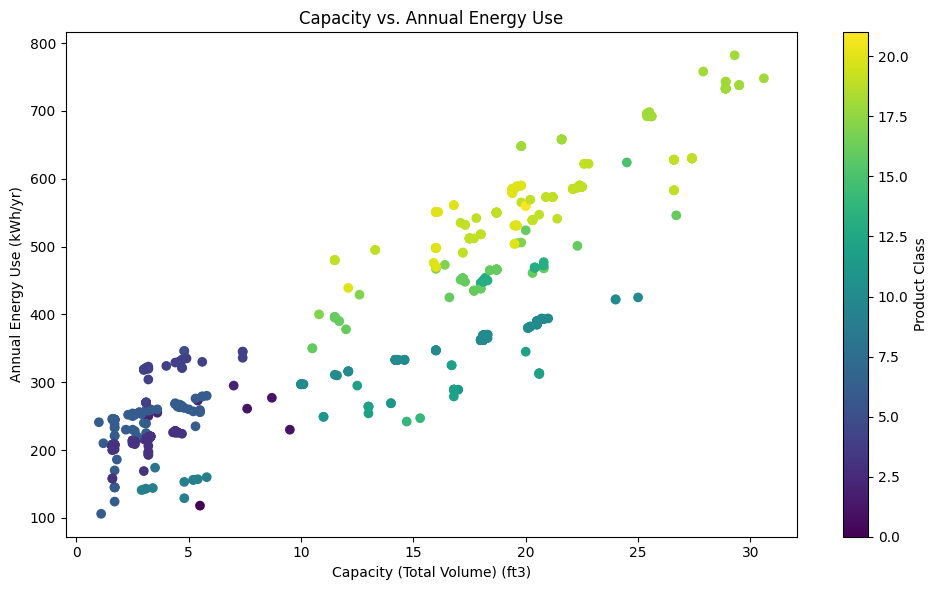

In [493]:
# Load the cleaned Residential Refrigerators dataset
df_refrigerators = pd.read_csv('Refrigerators_Cleaned.csv')


# Display basic statistics
print(df_refrigerators.describe())


# Confirming missing values = 0
missing_values = df_refrigerators.isnull().sum()
print("Missing values per column:\n", missing_values)


# Visualization: Scatter plot of Capacity vs. Annual Energy Use
plt.figure(figsize=(10, 6))
plt.scatter(df_refrigerators["Capacity (Total Volume) (ft3)"], df_refrigerators["Annual Energy Use (kWh/yr)"], c=df_refrigerators["Product Class"].astype('category').cat.codes, cmap="viridis")
plt.title("Capacity vs. Annual Energy Use")
plt.xlabel("Capacity (Total Volume) (ft3)")
plt.ylabel("Annual Energy Use (kWh/yr)")
plt.colorbar(label="Product Class")
plt.tight_layout()
plt.show()


#### Observations from the Refrigerator Data

- **Positive Trend:** Larger refrigerators use more energy, which makes sense since they have more space to cool.  

- **Clusters:** Product classes form clear groups, showing differences in efficiency and design. 
 
- **Outliers:** Some smaller fridges use more power than expected, while a few big ones are surprisingly efficient.


### Exploring the Room Air Conditioners Data

   ENERGY STAR Unique ID    Brand Name Model Number  \
0                3387785  Black+Decker     BD08NWES   
1                3387786  Black+Decker     BD10NWES   
2                3387787  Black+Decker     BD12NWES   
3                3629713       Century    RXTS-101A   
4                3629714       Century    RXTS-121A   

  Additional Model Information           UPC  Height (inches)  Width (inches)  \
0                          NaN  810064695360             13.5            18.6   
1                          NaN  810064695377             13.5            18.6   
2                          NaN  810064695384             14.6            19.1   
3                          NaN           NaN             13.5            19.2   
4                          NaN           NaN             13.5            19.2   

   Depth (inches)  Weight (lbs)  Cooling Capacity (Btu/hr)  ...  \
0            19.6          44.1                       8000  ...   
1            19.6          46.1                 

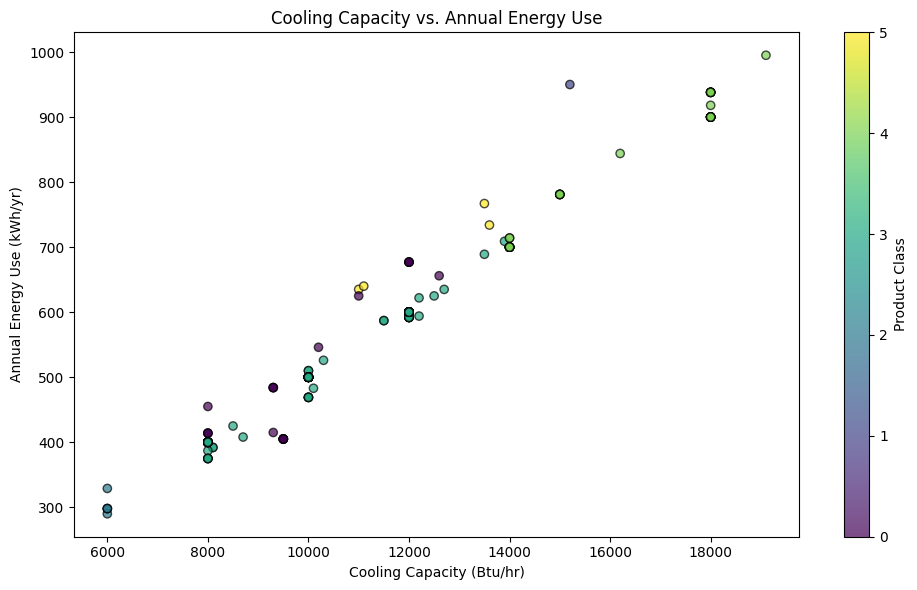

In [494]:
# Load dataset
df_ac = pd.read_csv('AirConditioners_Cleaned.csv')
print(df_ac.head())
# Basic info
print("Summary Stats:\n", df_ac.describe())
print("\nMissing Values:\n", df_ac.isnull().sum())

# Keep only rows with valid Cooling Capacity and Energy Use
cols = ["Cooling Capacity (Btu/hr)", "Annual Energy Use (kWh/yr)"]
df_plot = df_ac.dropna(subset=cols)

# Convert to numeric (remove commas, handle blanks)
for col in cols:
    df_plot[col] = (
        df_plot[col].astype(str).str.replace(',', '').str.strip().replace('', pd.NA)
    )
    df_plot[col] = pd.to_numeric(df_plot[col], errors='coerce')

# Drop any rows that failed conversion
df_plot = df_plot.dropna(subset=cols)

# Scatter plot
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df_plot[cols[0]],
    df_plot[cols[1]],
    c=df_plot["Product Class"].astype('category').cat.codes,
    cmap="viridis", alpha=0.7, edgecolor='k'
)
plt.title("Cooling Capacity vs. Annual Energy Use")
plt.xlabel("Cooling Capacity (Btu/hr)")
plt.ylabel("Annual Energy Use (kWh/yr)")
plt.colorbar(scatter, label="Product Class")
plt.tight_layout()
plt.show()


#### Observations from the Room Air Conditioners Data

- **Positive Trend:** Units with higher cooling capacity use more energy, which makes sense since bigger systems draw more power.  

- **Clusters:** Product classes form clear groups, showing differences in energy use and design.  

- **Outliers:** A few units use more energy than expected for their size, likely due to older or less efficient models.


### Exploring the Television Data

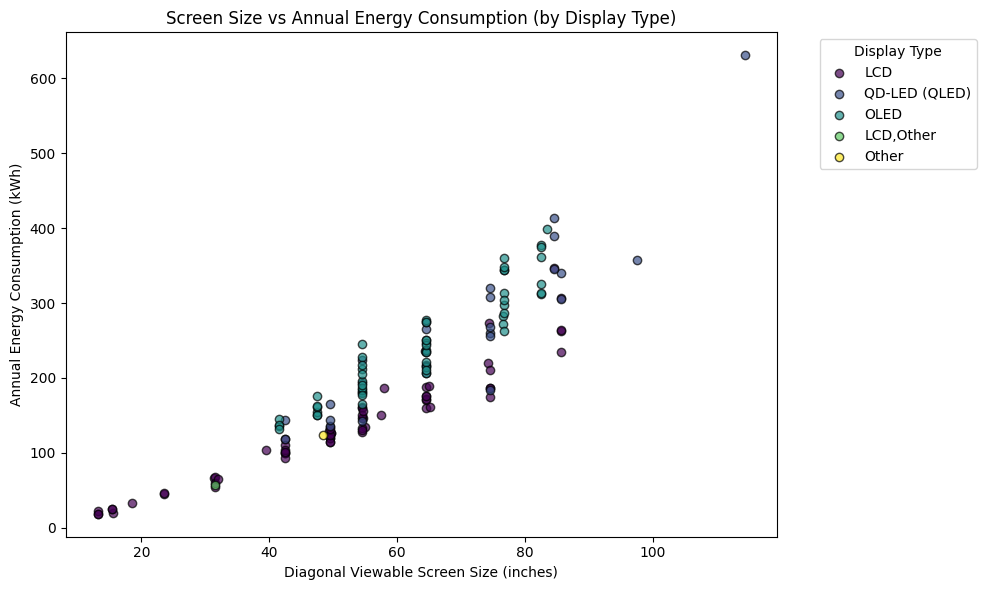

In [510]:
import matplotlib.pyplot as plt
import pandas as pd

# Load dataset
df_tv = pd.read_csv("Televisions_Cleaned.csv")

# Columns needed
size_col = "Diagonal Viewable Screen Size (in.)"
energy_col = "Reported Annual Energy Consumption (kWh)"
category_col = "Display Type"   # This exists in your dataset

# Keep valid rows only
df_plot = df_tv.dropna(subset=[size_col, energy_col, category_col])

# Convert numeric fields
df_plot[size_col] = pd.to_numeric(df_plot[size_col], errors='coerce')
df_plot[energy_col] = pd.to_numeric(df_plot[energy_col], errors='coerce')
df_plot = df_plot.dropna(subset=[size_col, energy_col])

# Scatter plot
plt.figure(figsize=(10, 6))

unique_categories = df_plot[category_col].unique()
colors = plt.cm.viridis(np.linspace(0, 1, len(unique_categories)))

for cat, color in zip(unique_categories, colors):
    subset = df_plot[df_plot[category_col] == cat]
    plt.scatter(
        subset[size_col],
        subset[energy_col],
        label=cat,
        color=color,
        alpha=0.7,
        edgecolor="k"
    )

plt.title("Screen Size vs Annual Energy Consumption (by Display Type)")
plt.xlabel("Diagonal Viewable Screen Size (inches)")
plt.ylabel("Annual Energy Consumption (kWh)")

# Add the legend
plt.legend(title="Display Type", bbox_to_anchor=(1.05, 1), loc="upper left")

plt.tight_layout()
plt.show()


#### Observations from the Television Data

- **Positive Trend:** Larger TVs clearly use more energy, which makes sense since bigger screens need more power. 

- **Size Groups:** TVs cluster around common screen sizes like 40", 55", and 65", showing standard product categories.  

- **Outliers:** A few large TVs use extra energy, likely due to older tech or higher brightness settings.


### Exploring the Ceiling Fans Data

Summary Stats:
        ENERGY STAR Unique ID  Blade Span (Diameter) (in.)  \
count           1.144000e+03                  1144.000000   
mean            3.170131e+06                    55.700175   
std             7.677942e+05                     9.041082   
min             2.313943e+06                    19.000000   
25%             2.389850e+06                    52.000000   
50%             2.856306e+06                    52.000000   
75%             3.943170e+06                    60.000000   
max             4.511663e+06                    84.000000   

       Ceiling Fan Efficiency (CFM/W)  Fan Power Consumption-Low Speed (W)  \
count                     1144.000000                          1082.000000   
mean                       209.056731                             4.651017   
std                         71.468044                             3.241647   
min                         47.400000                             1.000000   
25%                        157.500000       

/var/folders/10/k1hzxcd55vlfmyc_qrppm9980000gn/T/ipykernel_31404/2905857853.py:21: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  scatter = plt.scatter(


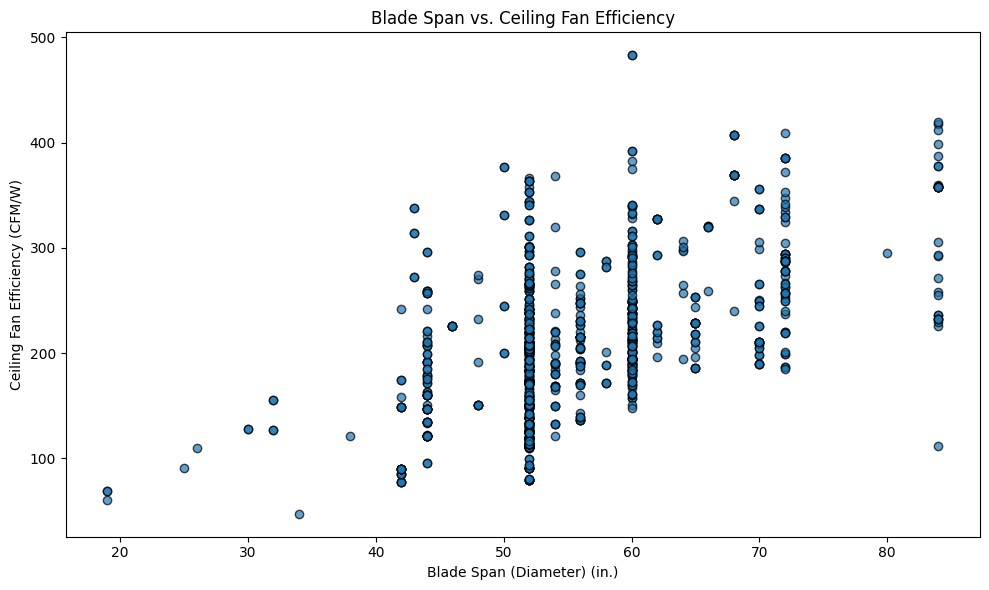

In [496]:
# Load dataset
df_fans = pd.read_csv('CeilingFans_Cleaned.csv')
print("Summary Stats:\n", df_fans.describe())

# Keep rows with valid efficiency and blade span values
cols = ["Ceiling Fan Efficiency (CFM/W)", "Blade Span (Diameter) (in.)"]
df_plot = df_fans.dropna(subset=cols)

# Convert numeric columns (remove commas and blanks)
for col in cols:
    df_plot[col] = pd.to_numeric(
        df_plot[col].astype(str).str.replace(',', '').str.strip().replace('', pd.NA),
        errors='coerce'
    )

# Drop invalid rows after conversion
df_plot = df_plot.dropna(subset=cols)

# Plot: Blade Span vs. Ceiling Fan Efficiency
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df_plot[cols[1]], df_plot[cols[0]],
    c=df_plot["Product Class"].astype('category').cat.codes if "Product Class" in df_plot.columns else None,
    cmap="viridis", alpha=0.7, edgecolor='k'
)
plt.title("Blade Span vs. Ceiling Fan Efficiency")
plt.xlabel("Blade Span (Diameter) (in.)")
plt.ylabel("Ceiling Fan Efficiency (CFM/W)")
if "Product Class" in df_plot.columns:
    plt.colorbar(scatter, label="Product Class")
plt.tight_layout()
plt.show()


#### Observations from the Ceiling Fans Data

- **Positive Correlation**: Larger blade spans tend to have higher efficiency, as expected, but the relationship isn't strong as there seems to be alot of variation in the middle range.

- **Distinct Clusters**: Product classes form clear groupings, indicating differences in design and efficiency.

- **Outliers:** A few small fans are surprisingly efficient, while some large fans underperform. This might be due to design differences or newer energy-saving models.

### Exploring the Ovens Data

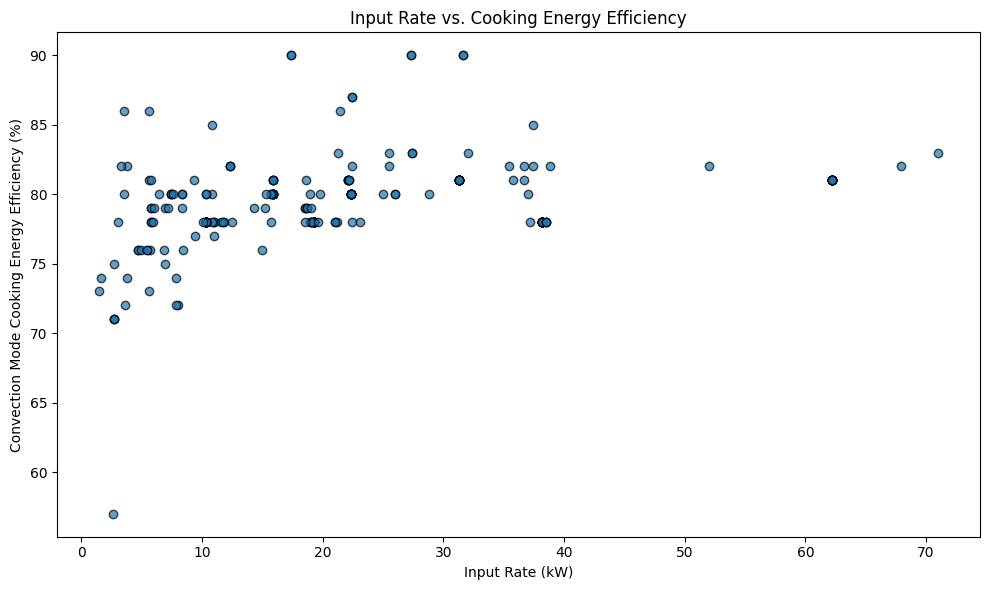

In [497]:
df = pd.read_csv('Ovens_Cleaned.csv')

# Clean data
df = df.dropna(subset=["Convection Mode Cooking Energy Efficiency (%)", "Input Rate (kW)"])
df["Convection Mode Cooking Energy Efficiency (%)"] = (
    df["Convection Mode Cooking Energy Efficiency (%)"].astype(str).str.replace(',', '').astype(float)
)
df["Input Rate (kW)"] = (
    df["Input Rate (kW)"].astype(str).str.replace(',', '').astype(float)
)

# Fix possible BTU/hr entries
df.loc[df["Input Rate (kW)"] > 1000, "Input Rate (kW)"] /= 3412

# Remove extreme outliers
df = df[df["Input Rate (kW)"] < 500]

# Plot
plt.figure(figsize=(10, 6))
plt.scatter(
    df["Input Rate (kW)"],
    df["Convection Mode Cooking Energy Efficiency (%)"],
    alpha=0.7, edgecolor='k'
)
plt.title("Input Rate vs. Cooking Energy Efficiency")
plt.xlabel("Input Rate (kW)")
plt.ylabel("Convection Mode Cooking Energy Efficiency (%)")
plt.tight_layout()
plt.show()


#### Observations from the Ovens Data

- **Weak Correlation:** Efficiency doesn’t change much with input rate. Bigger or more powerful ovens don’t always perform more efficiently — most seem to have similar efficiency levels overall.  

- **Efficiency Range:** Most ovens fall between **70–90% efficiency**, showing that they work pretty consistently overall.

- **Outliers:** A few ovens have **lower efficiency** than expected for their input rate, which could be due to older designs. Some smaller ovens actually perform really well, showing how newer designs are getting better.

- **Pattern:** Most ovens sit around **80% efficiency**, which seems to be the common performance level for most models.


## Part III: Data Visualizations

In this section, we are going to examine and explore the various trends based on our EDA. 

1. 2 Pie Charts (Biases: Size and Cost vs Emmissions)
2. 1 Bar Graph (Examining the trends of size and cost with Emmissions)


### Televisions Visualizations


/var/folders/10/k1hzxcd55vlfmyc_qrppm9980000gn/T/ipykernel_31404/3186377888.py:23: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  size_pie = df.groupby('Size Bin')[emissions_col].sum()


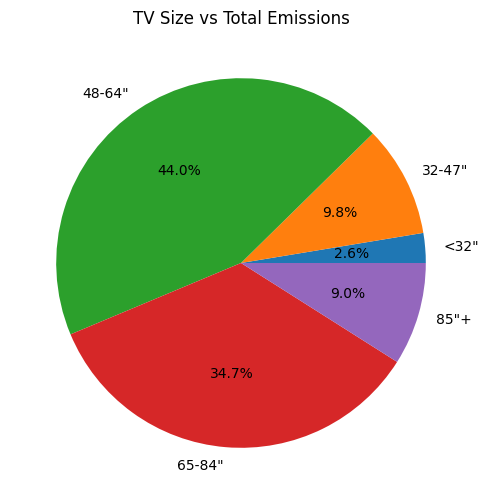

/var/folders/10/k1hzxcd55vlfmyc_qrppm9980000gn/T/ipykernel_31404/3186377888.py:34: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  power_pie = df.groupby('Power Bin')[emissions_col].sum()


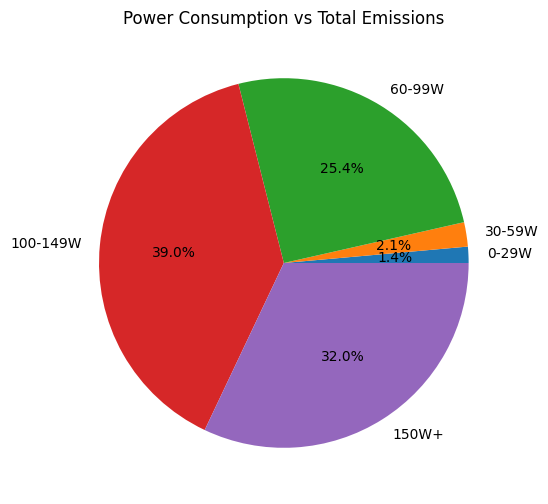

/var/folders/10/k1hzxcd55vlfmyc_qrppm9980000gn/T/ipykernel_31404/3186377888.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bar_data = df.groupby('Size Bin')[[emissions_col, power_col]].mean()


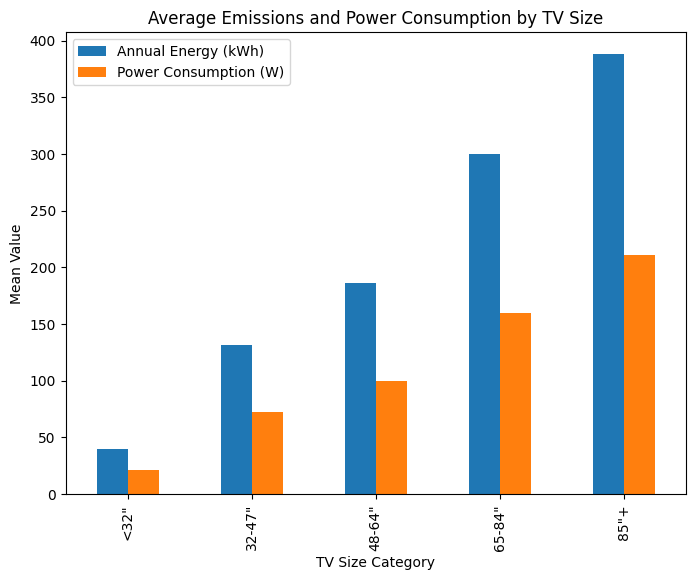

In [499]:
df = pd.read_csv('Televisions_Cleaned.csv')


size_col = 'Diagonal Viewable Screen Size (in.)'
emissions_col = 'Reported Annual Energy Consumption (kWh)'
power_col = 'Average On Mode Power Consumption for Certification (watts)'


df = df[[size_col, emissions_col, power_col]]
df = df.dropna()


size_bins = [0, 32, 48, 65, 85, df[size_col].max()]
size_labels = ['<32"', '32-47"', '48-64"', '65-84"', '85"+']
df['Size Bin'] = pd.cut(df[size_col], bins=size_bins, labels=size_labels)


emissions_bins = [0, 50, 100, 150, 200, df[emissions_col].max()]
emissions_labels = ['0-49 kWh', '50-99', '100-149', '150-199', '200+']
df['Emissions Bin'] = pd.cut(df[emissions_col], bins=emissions_bins, labels=emissions_labels)

# First Pie Chart: TV Size vs Total Emissions
size_pie = df.groupby('Size Bin')[emissions_col].sum()
plt.figure(figsize=(6, 6))
size_pie.plot.pie(autopct='%1.1f%%')
plt.title("TV Size vs Total Emissions")
plt.ylabel("")
plt.show()

# Second Pie Chart: Power Consumption vs Total Emissions
power_bins = [0, 30, 60, 100, 150, df[power_col].max()]
power_labels = ['0-29W', '30-59W', '60-99W', '100-149W', '150W+']
df['Power Bin'] = pd.cut(df[power_col], bins=power_bins, labels=power_labels)
power_pie = df.groupby('Power Bin')[emissions_col].sum()
plt.figure(figsize=(6, 6))
power_pie.plot.pie(autopct='%1.1f%%')
plt.title("Power Consumption vs Total Emissions")
plt.ylabel("")
plt.show()

# Bar Graph: Average Emissions and Power Consumption vs TV Size
bar_data = df.groupby('Size Bin')[[emissions_col, power_col]].mean()
bar_data.plot.bar(figsize=(8, 6))
plt.title("Average Emissions and Power Consumption by TV Size")
plt.xlabel("TV Size Category")
plt.ylabel("Mean Value")
plt.legend(["Annual Energy (kWh)", "Power Consumption (W)"])
plt.show()


Explanation of Visualizations:

### Ceiling Fans Visualizations

/var/folders/10/k1hzxcd55vlfmyc_qrppm9980000gn/T/ipykernel_31404/458241622.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  size_pie = df.groupby('Size Bin')[emissions_col].sum()


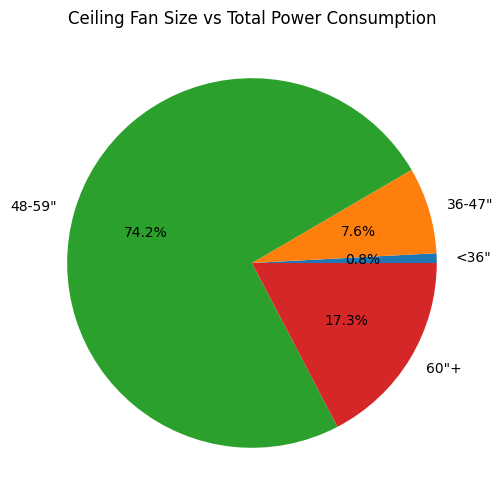

/var/folders/10/k1hzxcd55vlfmyc_qrppm9980000gn/T/ipykernel_31404/458241622.py:30: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  power_pie = df.groupby('Power Bin')[emissions_col].sum()


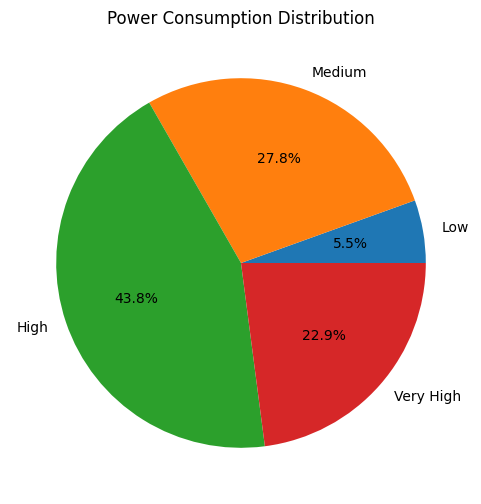

/var/folders/10/k1hzxcd55vlfmyc_qrppm9980000gn/T/ipykernel_31404/458241622.py:38: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bar_data = df.groupby('Size Bin')[emissions_col].mean()


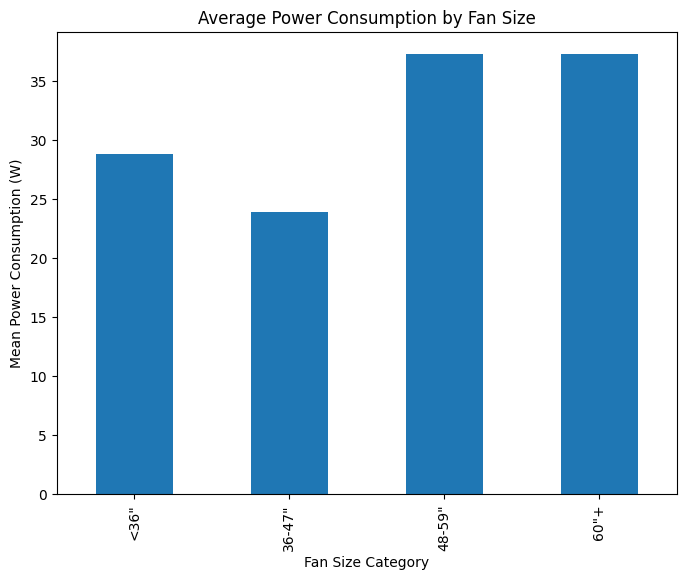

In [500]:
df = pd.read_csv('CeilingFans_Cleaned.csv')

size_col = 'Blade Span (Diameter) (in.)'
emissions_col = 'Fan Power Consumption-High Speed (W)'
power_col = emissions_col

df = df[[size_col, emissions_col]].dropna()
df[size_col] = pd.to_numeric(df[size_col], errors='coerce')
df[emissions_col] = pd.to_numeric(df[emissions_col], errors='coerce')

size_bins = [0, 36, 48, 60, df[size_col].max()]
size_labels = ['<36"', '36-47"', '48-59"', '60"+']
df['Size Bin'] = pd.cut(df[size_col], bins=size_bins, labels=size_labels, include_lowest=True)

min_power = df[power_col].min()
max_power = df[power_col].max()
power_bins = [min_power, 20, 30, 50, max_power]
power_labels = ['Low', 'Medium', 'High', 'Very High']
df['Power Bin'] = pd.cut(df[power_col], bins=power_bins, labels=power_labels, include_lowest=True)

# First Pie Chart: Fan Size vs Total Power Consumption
size_pie = df.groupby('Size Bin')[emissions_col].sum()
plt.figure(figsize=(6, 6))
size_pie.plot.pie(autopct='%1.1f%%')
plt.title("Ceiling Fan Size vs Total Power Consumption")
plt.ylabel("")
plt.show()

# Second Pie Chart: Power Consumption Distribution
power_pie = df.groupby('Power Bin')[emissions_col].sum()
plt.figure(figsize=(6, 6))
power_pie.plot.pie(autopct='%1.1f%%')
plt.title("Power Consumption Distribution")
plt.ylabel("")
plt.show()

# Bar Graph: Average Power Consumption by Fan Size
bar_data = df.groupby('Size Bin')[emissions_col].mean()
bar_data.plot.bar(figsize=(8, 6))
plt.title("Average Power Consumption by Fan Size")
plt.xlabel("Fan Size Category")
plt.ylabel("Mean Power Consumption (W)")
plt.show()


Explanation of Visualizations

### Air Conditioners Visualizations

Cooling Capacity Range: 6000 → 19100


/var/folders/10/k1hzxcd55vlfmyc_qrppm9980000gn/T/ipykernel_31404/3234424900.py:65: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cap_pie = df.groupby("Capacity Bin")[emissions_col].sum()


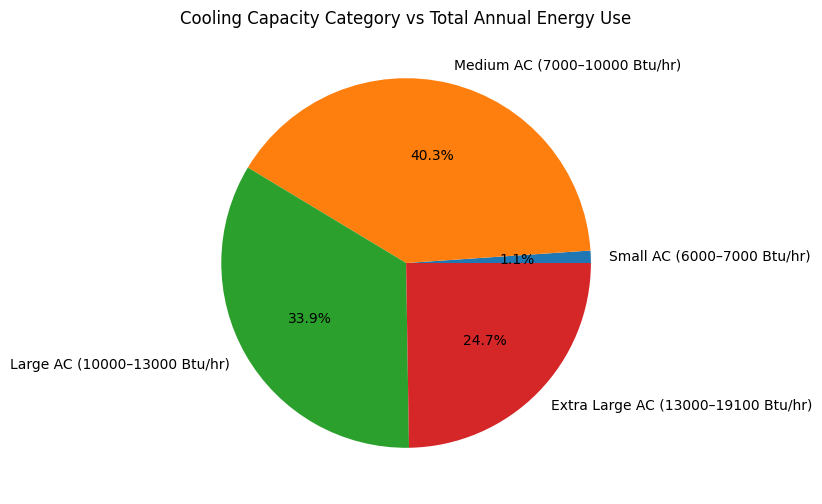

/var/folders/10/k1hzxcd55vlfmyc_qrppm9980000gn/T/ipykernel_31404/3234424900.py:75: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  energy_pie = df.groupby("Energy Bin")[emissions_col].sum()


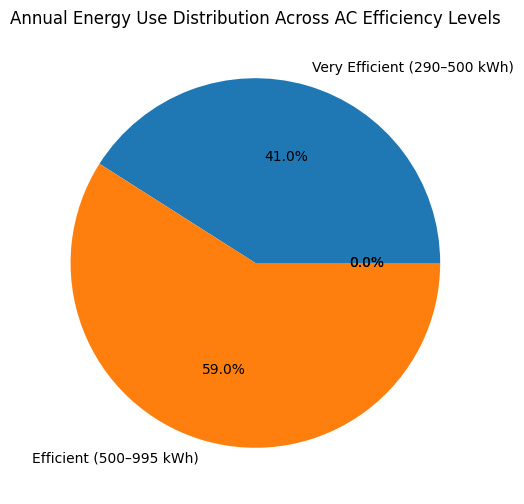

/var/folders/10/k1hzxcd55vlfmyc_qrppm9980000gn/T/ipykernel_31404/3234424900.py:85: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bar_data = df.groupby("Capacity Bin")[emissions_col].mean()


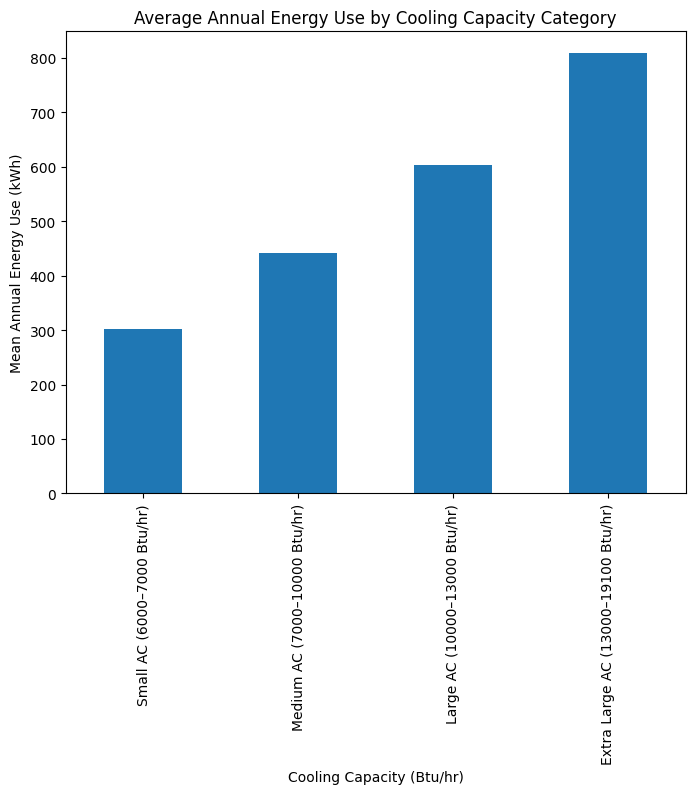

In [511]:
# Define Columns
df = pd.read_csv("AirConditioners_Cleaned.csv")
size_col = 'Cooling Capacity (Btu/hr)'
emissions_col = 'Annual Energy Use (kWh/yr)'
extra_col = 'Combined Energy Efficiency Ratio (CEER)'

# Convert Columns to Numeric
df[size_col] = df[size_col].astype(str).str.replace(",", "")
df[size_col] = pd.to_numeric(df[size_col], errors="coerce")

df[emissions_col] = pd.to_numeric(df[emissions_col], errors="coerce")
df[extra_col] = pd.to_numeric(df[extra_col], errors="coerce")

# Keep only useful columns
df = df[[size_col, emissions_col, extra_col]].dropna()


# COOLING CAPACITY BINS

print("Cooling Capacity Range:", df[size_col].min(), "→", df[size_col].max())

size_bins = [
    df[size_col].min(),   # Real minimum
    7000,                 # Small
    10000,                # Medium
    13000,                # Large
    df[size_col].max()    # Real maximum
]

# Remove duplicates (in case max < 13000)
size_bins = sorted(list(set(size_bins)))

size_labels = [
    f"Small AC ({size_bins[0]:.0f}–{size_bins[1]:.0f} Btu/hr)",
    f"Medium AC ({size_bins[1]:.0f}–{size_bins[2]:.0f} Btu/hr)",
    f"Large AC ({size_bins[2]:.0f}–{size_bins[3]:.0f} Btu/hr)",
    f"Extra Large AC ({size_bins[3]:.0f}–{size_bins[4]:.0f} Btu/hr)"
]

df["Capacity Bin"] = pd.cut(df[size_col], bins=size_bins,
                            labels=size_labels, include_lowest=True)


# FIXED ENERGY USE BINS

energy_min = df[emissions_col].min()
energy_max = df[emissions_col].max()

energy_bins = sorted(list(set([
    energy_min, 500, 1000, 1500, energy_max
])))

energy_labels = [
    f"Very Efficient ({energy_bins[0]:.0f}–{energy_bins[1]:.0f} kWh)",
    f"Efficient ({energy_bins[1]:.0f}–{energy_bins[2]:.0f} kWh)",
    f"High Use ({energy_bins[2]:.0f}–{energy_bins[3]:.0f} kWh)",
    f"Very High Use ({energy_bins[3]:.0f}–{energy_bins[4]:.0f} kWh)"
]

df["Energy Bin"] = pd.cut(df[emissions_col], bins=energy_bins,
                          labels=energy_labels, include_lowest=True)


# PLOT 1 — Pie Chart (Capacity vs Energy)
cap_pie = df.groupby("Capacity Bin")[emissions_col].sum()

plt.figure(figsize=(6, 6))
cap_pie.plot.pie(autopct="%1.1f%%")
plt.title("Cooling Capacity Category vs Total Annual Energy Use")
plt.ylabel("")
plt.show()


# PLOT 2 — Pie Chart (Energy Distribution)
energy_pie = df.groupby("Energy Bin")[emissions_col].sum()

plt.figure(figsize=(6, 6))
energy_pie.plot.pie(autopct="%1.1f%%")
plt.title("Annual Energy Use Distribution Across AC Efficiency Levels")
plt.ylabel("")
plt.show()


# PLOT 3 — Bar Chart (Average Emissions by Capacity Category)
bar_data = df.groupby("Capacity Bin")[emissions_col].mean()

plt.figure(figsize=(8, 6))
bar_data.plot.bar()
plt.title("Average Annual Energy Use by Cooling Capacity Category")
plt.xlabel("Cooling Capacity (Btu/hr)")
plt.ylabel("Mean Annual Energy Use (kWh)")
plt.show()


### Refrigerators Visualizations

/var/folders/10/k1hzxcd55vlfmyc_qrppm9980000gn/T/ipykernel_31404/624640481.py:50: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Size Bin")[emissions_col].sum().plot.pie(autopct='%1.1f%%')


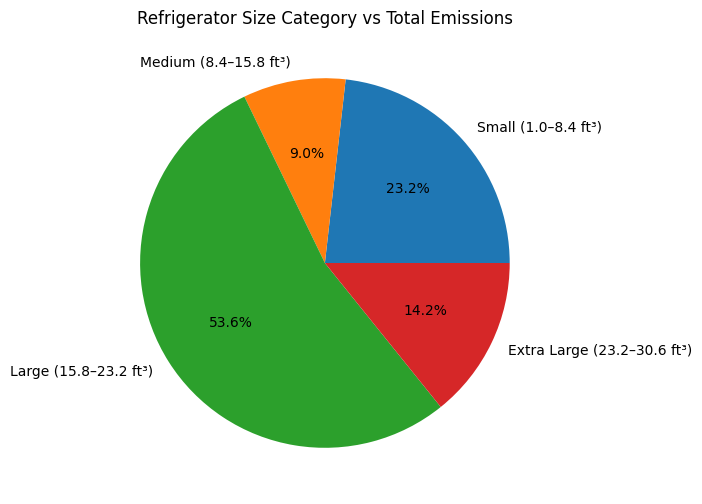

/var/folders/10/k1hzxcd55vlfmyc_qrppm9980000gn/T/ipykernel_31404/624640481.py:58: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Energy Bin")[emissions_col].sum().plot.pie(autopct='%1.1f%%')


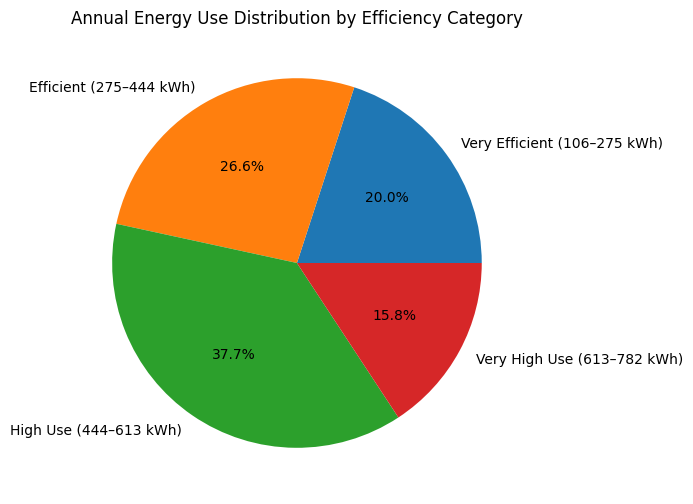

/var/folders/10/k1hzxcd55vlfmyc_qrppm9980000gn/T/ipykernel_31404/624640481.py:66: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Size Bin")[emissions_col].mean().plot.bar()


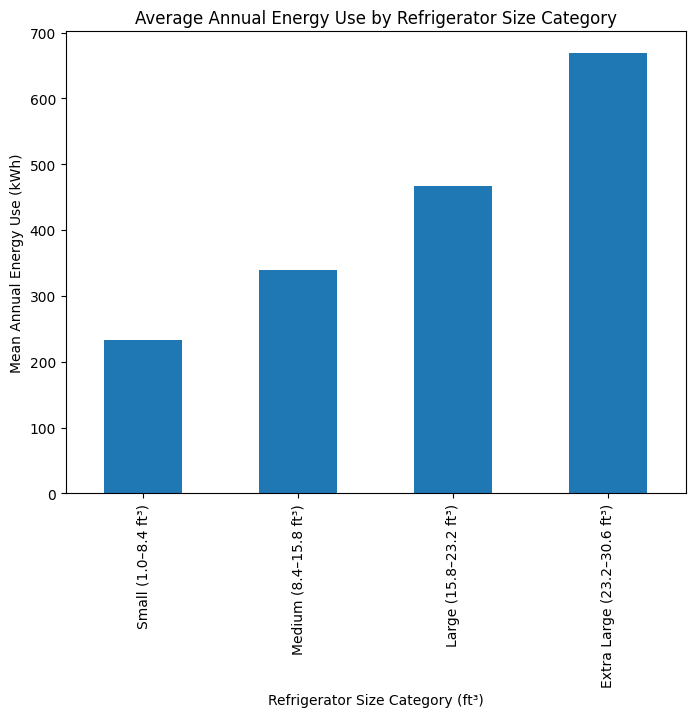

In [512]:
# 1. Load cleaned refrigerator dataset
df = pd.read_csv('Refrigerators_Cleaned.csv')


# 2. Select ONLY valid numeric columns
size_col = 'Capacity (Total Volume) (ft3)'
emissions_col = 'Annual Energy Use (kWh/yr)'

df[size_col] = pd.to_numeric(df[size_col], errors='coerce')
df[emissions_col] = pd.to_numeric(df[emissions_col], errors='coerce')
df["EfficiencyScore"] = df[emissions_col] / df[size_col]
df = df[[size_col, emissions_col, "EfficiencyScore"]].dropna()


# 3. Create Meaningful Size Bins
size_min = df[size_col].min()
size_max = df[size_col].max()

size_bins = np.linspace(size_min, size_max, 5)

# Create human-readable labels:
size_labels = [
    f"Small ({size_bins[0]:.1f}–{size_bins[1]:.1f} ft³)",
    f"Medium ({size_bins[1]:.1f}–{size_bins[2]:.1f} ft³)",
    f"Large ({size_bins[2]:.1f}–{size_bins[3]:.1f} ft³)",
    f"Extra Large ({size_bins[3]:.1f}–{size_bins[4]:.1f} ft³)"
]

df["Size Bin"] = pd.cut(df[size_col], bins=size_bins, labels=size_labels, include_lowest=True)


# 4. Create Meaningful Energy Bins
energy_min = df[emissions_col].min()
energy_max = df[emissions_col].max()

energy_bins = np.linspace(energy_min, energy_max, 5)

energy_labels = [
    f"Very Efficient ({energy_bins[0]:.0f}–{energy_bins[1]:.0f} kWh)",
    f"Efficient ({energy_bins[1]:.0f}–{energy_bins[2]:.0f} kWh)",
    f"High Use ({energy_bins[2]:.0f}–{energy_bins[3]:.0f} kWh)",
    f"Very High Use ({energy_bins[3]:.0f}–{energy_bins[4]:.0f} kWh)"
]

df["Energy Bin"] = pd.cut(df[emissions_col], bins=energy_bins, labels=energy_labels, include_lowest=True)


# 5. Pie Chart — Size vs Total Emissions
plt.figure(figsize=(6, 6))
df.groupby("Size Bin")[emissions_col].sum().plot.pie(autopct='%1.1f%%')
plt.title("Refrigerator Size Category vs Total Emissions")
plt.ylabel("")
plt.show()


# 6. Pie Chart — Energy Use Distribution
plt.figure(figsize=(6, 6))
df.groupby("Energy Bin")[emissions_col].sum().plot.pie(autopct='%1.1f%%')
plt.title("Annual Energy Use Distribution by Efficiency Category")
plt.ylabel("")
plt.show()


# 7. Bar Chart — Average Emissions by Size
plt.figure(figsize=(8, 6))
df.groupby("Size Bin")[emissions_col].mean().plot.bar()
plt.title("Average Annual Energy Use by Refrigerator Size Category")
plt.xlabel("Refrigerator Size Category (ft³)")
plt.ylabel("Mean Annual Energy Use (kWh)")
plt.show()


### Ovens Visualizations

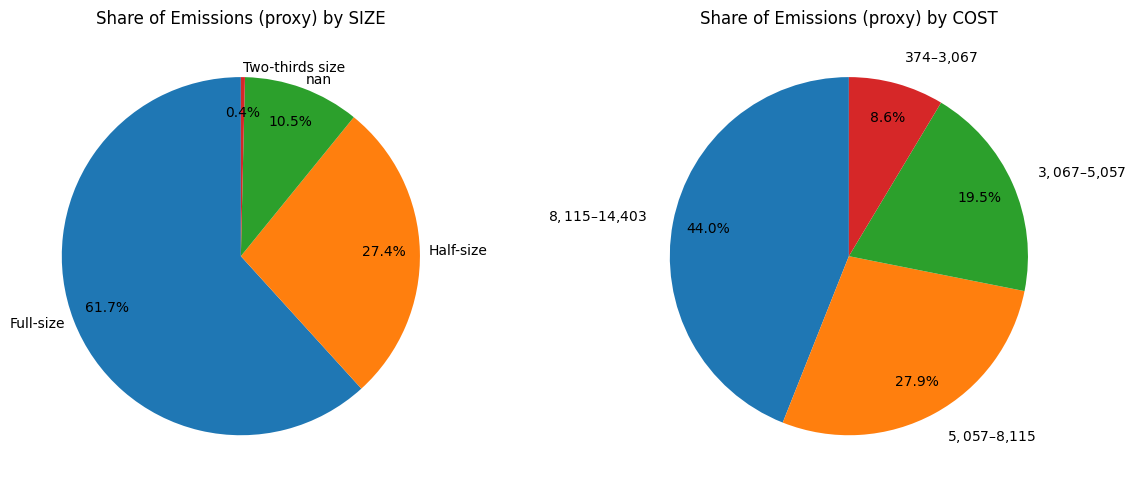

/var/folders/10/k1hzxcd55vlfmyc_qrppm9980000gn/T/ipykernel_31404/2751731783.py:140: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bar_data = df_eff.groupby("EfficiencyGroup")["Emissions"].mean()


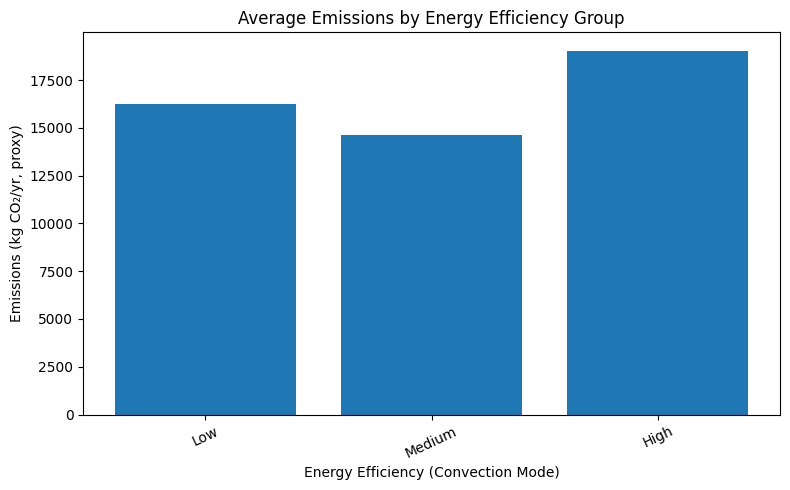

In [513]:
df = pd.read_csv("Ovens_Cleaned.csv")

def to_num(s):
    return pd.to_numeric(s.astype(str).str.replace(r"[,$]", "", regex=True), errors="coerce")

kw_col = "Input Rate (kW)"
btu_col = "Input Rate (Btu/hr)"
fuel_col = "Heat Source Fuel Type"
size_col = "Size"

df[kw_col]  = to_num(df[kw_col])
df[btu_col] = to_num(df[btu_col])

need_kw = df[kw_col].isna() & df[btu_col].notna()
df.loc[need_kw, kw_col] = df.loc[need_kw, btu_col] / 3412.14

df = df[(df[kw_col].notna()) & (df[kw_col] > 0) & (df[kw_col] < 60)]

HOURS_PER_YEAR = 2000
KG_CO2_PER_KWH = 0.386   
PRICE_PER_KWH  = 0.13

df["Emissions"]   = df[kw_col] * HOURS_PER_YEAR * KG_CO2_PER_KWH   
df["AnnualCost$"] = df[kw_col] * HOURS_PER_YEAR * PRICE_PER_KWH    

def topn_with_other(series, values, n=5, min_share=0.02):
    totals = values.groupby(series).sum().sort_values(ascending=False)
    if len(totals) <= n:
        return totals
    top = totals.head(n)
    other_val = totals[n:].sum()
    small = top[top / totals.sum() < min_share].sum()
    top = top[top / totals.sum() >= min_share]
    other_val += small
    if other_val > 0:
        top.loc["Other"] = other_val
    return top.sort_values(ascending=False)

em_by_size = topn_with_other(df[size_col].astype(str).str.strip(), df["Emissions"], n=5)

valid_cost = df["AnnualCost$"].dropna()
q = pd.qcut(valid_cost, q=4, duplicates="drop")
edges = q.cat.categories
labels = [f"${edges[i].left:,.0f}–${edges[i].right:,.0f}" for i in range(len(edges))]
bucket_map = dict(zip(edges.astype(str), labels))
cost_bucket = pd.Series(index=df.index, dtype="object")
cost_bucket.loc[q.index] = q.astype(str).map(bucket_map)

em_by_cost = topn_with_other(cost_bucket.fillna("Unknown"), df["Emissions"], n=6)

fig, ax = plt.subplots(1, 2, figsize=(12, 5))

ax[0].pie(
    em_by_size.values,
    labels=em_by_size.index,
    autopct="%1.1f%%",
    pctdistance=0.8,
    labeldistance=1.05,
    startangle=90
)
ax[0].set_title("Share of Emissions (proxy) by SIZE")

ax[1].pie(
    em_by_cost.values,
    labels=em_by_cost.index,
    autopct="%1.1f%%",
    pctdistance=0.8,
    labeldistance=1.15,
    startangle=90
)
ax[1].set_title("Share of Emissions (proxy) by COST")

plt.tight_layout()
plt.show()

# ---------- helpers ----------
def to_num(s):
    return pd.to_numeric(s.astype(str).str.replace(r"[,$]", "", regex=True), errors="coerce")

def topn_with_other(series, values, n=5, min_share=0.02):
    totals = values.groupby(series).sum().sort_values(ascending=False)
    if len(totals) <= n:
        return totals
    top = totals.head(n)
    other_val = totals[n:].sum()
    small = top[top / totals.sum() < min_share].sum()
    top = top[top / totals.sum() >= min_share]
    other_val += small
    if other_val > 0:
        top.loc["Other"] = other_val
    return top.sort_values(ascending=False)

# ---------- clean power / convert ----------
kw_col  = "Input Rate (kW)"
btu_col = "Input Rate (Btu/hr)"
size_col = "Size"

df[kw_col]  = to_num(df[kw_col])
df[btu_col] = to_num(df[btu_col])

# Fill missing kW from BTU/hr (1 kW = 3412.14 Btu/hr)
need_kw = df[kw_col].isna() & df[btu_col].notna()
df.loc[need_kw, kw_col] = df.loc[need_kw, btu_col] / 3412.14

# Remove non-sense / extreme outliers
df = df[(df[kw_col].notna()) & (df[kw_col] > 0) & (df[kw_col] < 60)]

# ---------- simple proxies ----------
HOURS_PER_YEAR = 2000
KG_CO2_PER_KWH = 0.386   # proxy emission factor
PRICE_PER_KWH  = 0.13    # proxy energy price

df["Emissions"]    = df[kw_col] * HOURS_PER_YEAR * KG_CO2_PER_KWH   # kg CO2/yr (proxy)
df["AnnualCost$"]  = df[kw_col] * HOURS_PER_YEAR * PRICE_PER_KWH    # $/yr (proxy)

# ---------- pies ----------
# Size vs Emissions (top-N + Other to keep labels readable)
em_by_size = topn_with_other(df[size_col].astype(str).str.strip(), df["Emissions"], n=5)

# Cost buckets vs Emissions (quartiles, pretty labels)
valid_cost = df["AnnualCost$"].dropna()
q = pd.qcut(valid_cost, q=4, duplicates="drop")
edges = q.cat.categories
labels = [f"${edges[i].left:,.0f}–${edges[i].right:,.0f}" for i in range(len(edges))]
bucket_map = dict(zip(edges.astype(str), labels))
cost_bucket = pd.Series(index=df.index, dtype="object")
cost_bucket.loc[q.index] = q.astype(str).map(bucket_map)
em_by_cost = topn_with_other(cost_bucket.fillna("Unknown"), df["Emissions"], n=6)

# ---------- BAR chart ----------
eff_col = "Convection Mode Cooking Energy Efficiency (%)"
if eff_col in df.columns:
    df[eff_col] = to_num(df[eff_col])
    df_eff = df[[eff_col, "Emissions"]].dropna()
    if df_eff[eff_col].nunique() >= 3:
        df_eff["EfficiencyGroup"] = pd.qcut(df_eff[eff_col], 3, labels=["Low", "Medium", "High"])
        bar_data = df_eff.groupby("EfficiencyGroup")["Emissions"].mean()
        xlab = "Energy Efficiency (Convection Mode)"
        title = "Average Emissions by Energy Efficiency Group"
    else:
        # not enough variation; fall back to Size
        bar_data = df.groupby("Size")["Emissions"].mean().sort_values(ascending=False)
        xlab = "Oven Size"
        title = "Average Emissions by Size"
else:
    bar_data = df.groupby("Size")["Emissions"].mean().sort_values(ascending=False)
    xlab = "Oven Size"
    title = "Average Emissions by Size"

plt.figure(figsize=(8,5))
plt.bar(bar_data.index, bar_data.values)
plt.title(title)
plt.xlabel(xlab)
plt.ylabel("Emissions (kg CO₂/yr, proxy)")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

## Part IV: ML Analysis

In this section, we are going to conduct analysis on our dataset using Machine Learning to predict if CO2 emmissions can be predicted. 

### Oven ML Analysis
For the very first Machine Learning Analysis of our project, we are going to look at the dataset for **ovens**. In the oven dataset, there are many features that could possibly cause high or low carbon dioxide emissions. 

#### Step 0: Prepare the data for ML Analysis

In the sections before this, we have prepared the data by cleaning out the NULL values and getting rid of any discrepancies within the data. In the EDA, we examined the data to look for any abnormalities in the data visually. Now, for this ML analysis part, we are going to examine the data at a much more scrutiny to predict CO2 emmissions. 

In [504]:
dfOvens = pd.read_csv("Ovens_Cleaned.csv")
print(dfOvens.info())

dfOvensML = dfOvens.copy()

# Convert BTU → kW
dfOvensML["InputRate_kW_from_BTU"] = dfOvensML["Input Rate (Btu/hr)"] / 3412.142

# Create unified InputRate_kW column
dfOvensML["InputRate_kW"] = dfOvensML["Input Rate (kW)"].fillna(dfOvensML["InputRate_kW_from_BTU"])

# Drop missing rows for the REAL columns
dfOvensML = dfOvensML.dropna(subset=["InputRate_kW", "Heat Source Fuel Type"])

# CO2 emissions
dfOvensML["CO2_Emissions"] = dfOvensML["InputRate_kW"] * 0.000394

dfOvensML.head()

dfOvensML["Heat Source Fuel Type"].value_counts()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 331 entries, 0 to 330
Data columns (total 48 columns):
 #   Column                                                      Non-Null Count  Dtype  
---  ------                                                      --------------  -----  
 0   ENERGY STAR Unique ID                                       331 non-null    int64  
 1   ENERGY STAR Partner                                         331 non-null    object 
 2   Brand Name                                                  331 non-null    object 
 3   Model Name                                                  331 non-null    object 
 4   Model Number                                                331 non-null    object 
 5   Additional Model Information                                104 non-null    object 
 6   UPC                                                         11 non-null     object 
 7   Product Type                                                331 non-null    object 
 8   

Heat Source Fuel Type
Electric    237
Gas          94
Name: count, dtype: int64

### Machine Learning Analysis #2: Predicting Oven Carbon Dioxide Emissions with Features

In this step, we are going to analyze if all we need for our ML analysis to determine whether or not we can predict CO2 emissions is by using the Heat Sources (i.e. gas and electric)

===== ML #1 — CLASSIFICATION RESULTS =====
Accuracy: 0.530


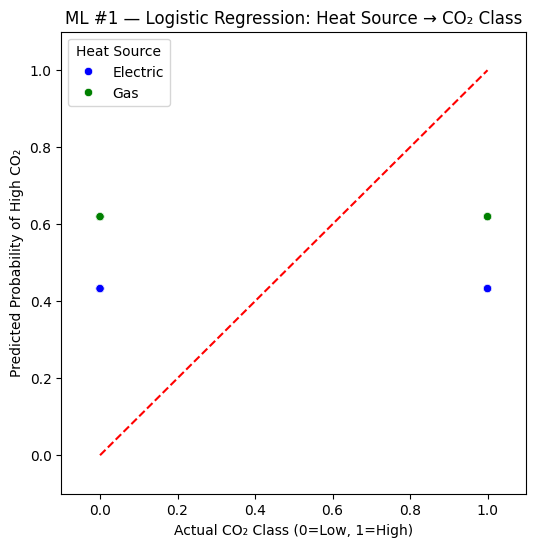

In [505]:
# 1. Create binary classes: High vs Low CO₂
median_CO2 = dfOvensML["CO2_Emissions"].median()
dfOvensML["HighCO2"] = (dfOvensML["CO2_Emissions"] > median_CO2).astype(int)

# Convert heat source to numeric
dfOvensML["HeatSourceEncoded"] = dfOvensML["Heat Source Fuel Type"].map({"Gas": 1, "Electric": 0})

# Drop rows with missing encoded values
dfOvensML = dfOvensML.dropna(subset=["HeatSourceEncoded"])


# 2. Train/Test Split
X = dfOvensML[["HeatSourceEncoded"]]
y = dfOvensML["HighCO2"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)


# 3. Logistic Regression Model
clf = LogisticRegression()
clf.fit(X_train, y_train)

y_prob = clf.predict_proba(X_test)[:, 1]   # Probability of High CO₂
y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print("===== ML #1 — CLASSIFICATION RESULTS =====")
print(f"Accuracy: {accuracy:.3f}")

# 4. Visualization — Probability vs Actual Class
plt.figure(figsize=(6,6))
sns.scatterplot(
    x=y_test,
    y=y_prob,
    hue=X_test["HeatSourceEncoded"].map({1: "Gas", 0: "Electric"}),
    palette=["blue", "green"]
)

# 45-degree reference line
plt.plot([0,1], [0,1], "--", color="red")

plt.xlabel("Actual CO₂ Class (0=Low, 1=High)")
plt.ylabel("Predicted Probability of High CO₂")
plt.title("ML #1 — Logistic Regression: Heat Source → CO₂ Class")
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)
plt.legend(title="Heat Source")
plt.show()

From this, it is clear that we need to have more features to classify whether or not an oven will produce low or high CO2.  

Looking at the dataset, there seems to be many features that could be used to predict CO2 emmissions. For this ML analysis, we are going to examine these features:
1. "HeatSourceEncoded": Heat Surce Fuel Type but mapped to either 1 or 0 for gas and electric
2. "Oven Classification": Type I, Type II (Table Countertop for Type I or Floor and Roll in units for Type II)
3. "Size" (Various sizes of the oven),
4. "Baking Production Capacity (lbs/hr)"

### Improvement of classification with more features!!!

===== ML #1 — Improved Classification =====
Accuracy: 0.833


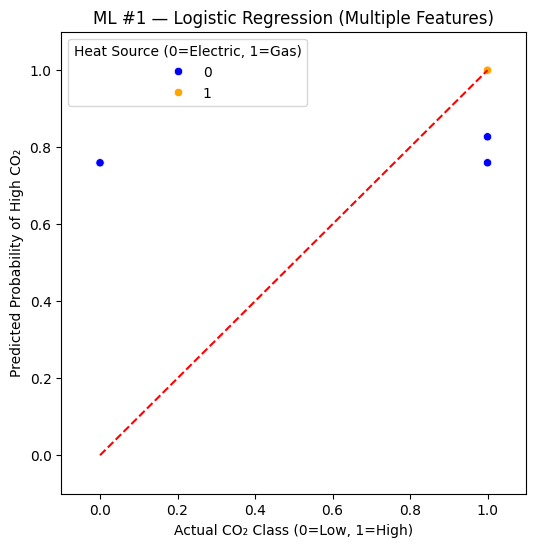

In [506]:
# 1. Create High vs Low CO₂ class
median_CO2 = dfOvensML["CO2_Emissions"].median()
dfOvensML["HighCO2"] = (dfOvensML["CO2_Emissions"] > median_CO2).astype(int)


# 2. Encode "Heat Source Fuel Type"
dfOvensML["HeatSourceEncoded"] = dfOvensML["Heat Source Fuel Type"].map({"Gas": 1, "Electric": 0})


# 3. Encode ALL categorical features


categorical_cols = [
    "Oven Classification",
    "Size",
    "Method of Steam Generation"
]

dfOvensML_encoded = dfOvensML.copy()

for col in categorical_cols:
    le = LabelEncoder()
    dfOvensML_encoded[col] = le.fit_transform(dfOvensML_encoded[col].astype(str))


# 4. Select MULTIPLE FEATURES
features = [
    "HeatSourceEncoded",
    "Oven Classification",
    "Size",
    "Baking Production Capacity (lbs/hr)"
]

df_model = dfOvensML_encoded[features + ["HighCO2"]].dropna()

X = df_model[features]
y = df_model["HighCO2"]

# 5. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# 6. Logistic Regression Model
clf = LogisticRegression(max_iter=500)
clf.fit(X_train, y_train)

y_prob = clf.predict_proba(X_test)[:, 1]
y_pred = clf.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("===== ML #1 — Improved Classification =====")
print(f"Accuracy: {accuracy:.3f}")

# 7. Visualization (color by heat source)
plt.figure(figsize=(6,6))
sns.scatterplot(
    x=y_test,
    y=y_prob,
    hue=X_test["HeatSourceEncoded"],
    palette=["blue", "orange"]
)

plt.plot([0,1], [0,1], "--", color="red")
plt.xlabel("Actual CO₂ Class (0=Low, 1=High)")
plt.ylabel("Predicted Probability of High CO₂")
plt.title("ML #1 — Logistic Regression (Multiple Features)")
plt.xlim(-0.1, 1.1)
plt.ylim(-0.1, 1.1)
plt.legend(title="Heat Source (0=Electric, 1=Gas)")
plt.show()


Now, we are able to distinguish and predict what ovens will produce high Carbon Dioxide and low Carbon Dioxide based on certain features using Machine Learning with a 83.3% accuracy.   

In our second Machine Learning Analysis, we are going to make a regression model using these features to determine a function that can accurately determine how much carbon dioxide will be emitted based on an oven with inputs as the Heat Source, the input rate, the convection mode cooking energy efficiency, the steam mode cooking energy efficiency, the convection mode production capacity, and the steam mode production capacity. 

### Machine Learning Analysis #2: Predicting Oven Carbon Dioxide Emissions with Features

===== ML #2 — REGRESSION RESULTS =====
Baseline MSE: 0.000092
R² Score: -0.126023
Model MSE: 0.000033
Model R² Score: 0.602264

Feature Coefficients:
  HeatSourceEncoded: 10.387342
  Oven Classification: -21.162393
  Size: 2.367043
  Baking Production Capacity (lbs/hr): 0.258500

===== Linear Regression Equation =====
InputRate_kW = 24.652274 + (10.387342)*HeatSourceEncoded + (-21.162393)*Oven Classification + (2.367043)*Size + (0.258500)*Baking Production Capacity (lbs/hr)

===== CO₂ Emissions Equation (metric tons) =====
CO2 = 0.009713 + (0.004093)*HeatSourceEncoded + (-0.008338)*Oven Classification + (0.000933)*Size + (0.000102)*Baking Production Capacity (lbs/hr)


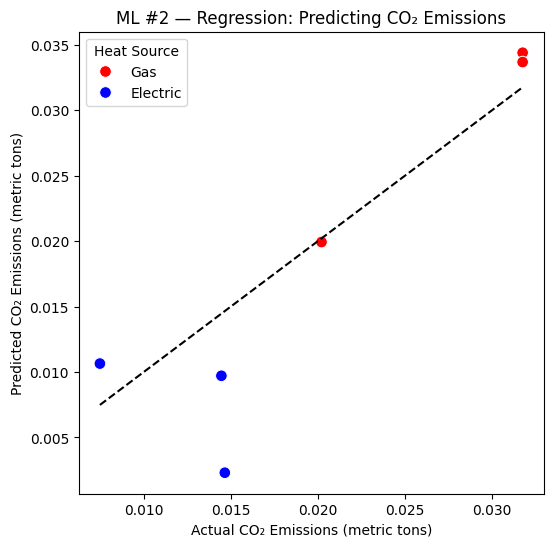

In [522]:
# ======================================================
# ML #2 — Predict Carbon Dioxide Emissions (Proper ML)
# ======================================================

df2 = dfOvensML.copy()


# 1. Select meaningful features
features = [
    "HeatSourceEncoded",
    "Oven Classification",
    "Size",
    "Baking Production Capacity (lbs/hr)"
]

target = "InputRate_kW"  # Predict energy input → later convert to CO₂



# 2. Encode categorical features
cat_cols = ["Oven Classification", "Size"]

le = LabelEncoder()

for col in cat_cols:
    df2[col] = le.fit_transform(df2[col].astype(str))



# 3. Drop rows missing any feature or target
df2 = df2.dropna(subset=features + [target])

X = df2[features]
y = df2[target]



# 4. Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42
)

# 5. Baseline: Predict mean InputRate_kW
baseline_pred = np.full_like(y_test, y_train.mean())
baseline_mse = mean_squared_error(y_test * 3.94e-4, baseline_pred * 3.94e-4)
# Convert to CO₂ (like your ML predictions)
baseline_pred_CO2 = baseline_pred * 3.94e-4
y_test_CO2 = y_test * 3.94e-4
# Baseline R²
baseline_r2 = r2_score(y_test_CO2, baseline_pred_CO2)


# 6. Linear Regression Model
reg = LinearRegression()
reg.fit(X_train, y_train)

y_pred_input = reg.predict(X_test)


# ------------------------------------------------------
# 7. Convert InputRate_kW → CO₂ (metric tons)
#    EPA conversion factor:
#    3.94e-4 metric tons CO₂ per kWh
# ------------------------------------------------------
y_test_CO2 = y_test * 3.94e-4
y_pred_CO2 = y_pred_input * 3.94e-4



# 8. Evaluate
mse = mean_squared_error(y_test_CO2, y_pred_CO2)
r2 = r2_score(y_test_CO2, y_pred_CO2)

print("===== ML #2 — REGRESSION RESULTS =====")
print(f"Baseline MSE: {baseline_mse:.6f}")
print(f"R² Score: {baseline_r2:.6f}")
print(f"Model MSE: {mse:.6f}")
print(f"Model R² Score: {r2:.6f}\n")

print("Feature Coefficients:")
for name, coef in zip(features, reg.coef_):
    print(f"  {name}: {coef:.6f}")

# -----------------------------------------
# Print the Regression Equation
# CO₂ = b0 + b1*x1 + b2*x2 + ...
# -----------------------------------------

intercept = reg.intercept_
coeffs = reg.coef_

print("\n===== Linear Regression Equation =====")
equation = f"InputRate_kW = {intercept:.6f}"

for name, coef in zip(features, coeffs):
    equation += f" + ({coef:.6f})*{name}"

print(equation)

# Convert entire equation to CO₂ emissions
print("\n===== CO₂ Emissions Equation (metric tons) =====")
equation_CO2 = f"CO2 = {intercept*3.94e-4:.6f}"

for name, coef in zip(features, coeffs):
    equation_CO2 += f" + ({coef*3.94e-4:.6f})*{name}"

print(equation_CO2)



# 8. Plot Predicted vs Actual CO₂ Emissions
heat_labels = {0: "Electric", 1: "Gas"}

plt.figure(figsize=(6,6))
sns.scatterplot(
    x=y_test_CO2,
    y=y_pred_CO2,
    hue=X_test["HeatSourceEncoded"].map(heat_labels),
    palette={"Electric": "blue", "Gas": "red"},
    s=70
)

# 45-degree line
plt.plot([y_test_CO2.min(), y_test_CO2.max()],
         [y_test_CO2.min(), y_test_CO2.max()],
         "--", color="black")

plt.xlabel("Actual CO₂ Emissions (metric tons)")
plt.ylabel("Predicted CO₂ Emissions (metric tons)")
plt.title("ML #2 — Regression: Predicting CO₂ Emissions")
plt.legend(title="Heat Source")
plt.show()


From this, we have successfully created a regression line that can be used to predict how much Carbon Dioxide an oven emits as long as we have the oven heat source classification, oven classification, size, and baking production capacity. We are able to do this with the equation that we have from the regression line. Furthermore, our ML analysis is correct as our R^2 is correct (close to 1 and positive) with our MSE being really low. 